In [1]:
import matplotlib.pyplot as plt
import pandas as pd

In [11]:
# cherrypick lol
imdb_path = "dlm_steer_results/42_imdb_manualsearch_csv"
catdog_path = "dlm_steer_results/42_cats_dogs_manualsearch_csv"

imdb_paths_cherry = [
    "dlm_steer_results/42_imdb_manualsearch_csv/from_negative-rs15-st0.5-it0.5.csv",
    "dlm_steer_results/42_imdb_manualsearch_csv/from_positive-rs15-st0.5-it0.5.csv",
]

catdog_paths_cherry = [
    "dlm_steer_results/42_cats_dogs_manualsearch_csv/from_cat-rs15-st0.5-it0.5.csv",
    "dlm_steer_results/42_cats_dogs_manualsearch_csv/from_dog-rs15-st0.5-it0.5.csv",
]

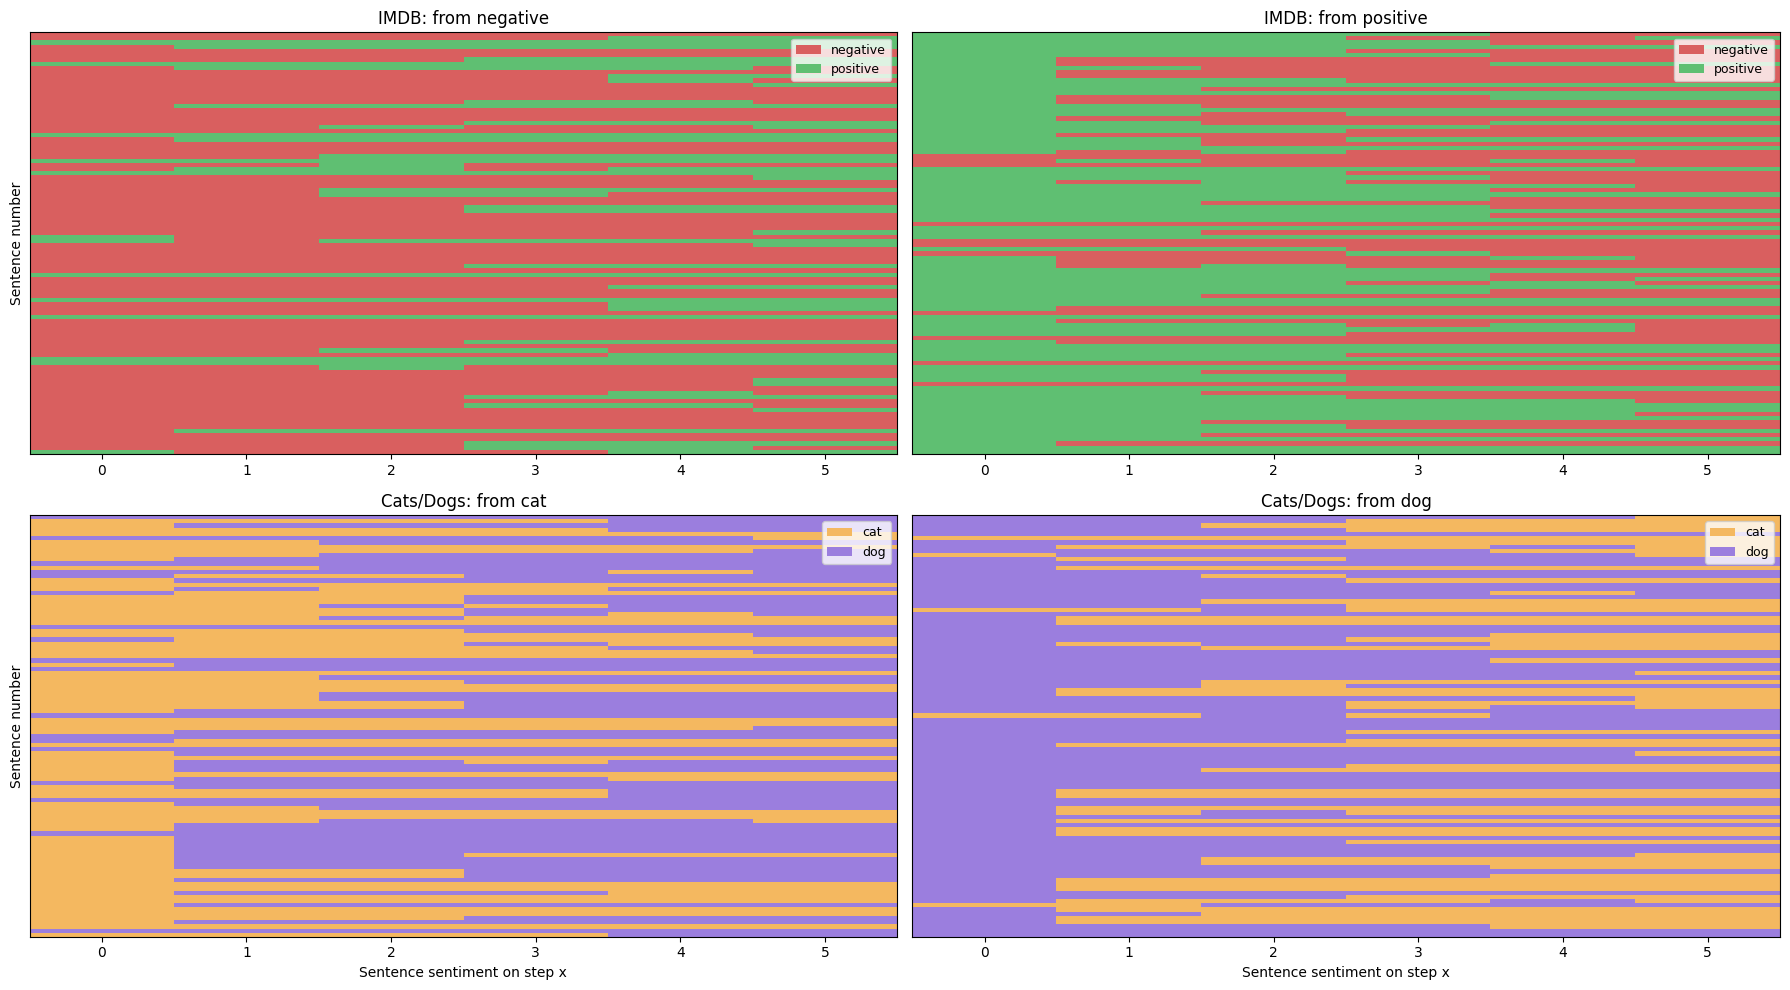

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

all_paths = imdb_paths_cherry + catdog_paths_cherry

all_titles = [
    "IMDB: from negative",
    "IMDB: from positive",
    "Cats/Dogs: from cat",
    "Cats/Dogs: from dog",
]

fig, axes = plt.subplots(2, 2, figsize=(18, 10))

for i, (ax, path, title) in enumerate(zip(axes.ravel(), all_paths, all_titles)):
    df = pd.read_csv(path)

    random_100 = (
        df["instance_number"]
        .drop_duplicates()
        .sample(n=100, random_state=67)
    )

    df = df[df["instance_number"].isin(random_100)].copy()

    df["step"] = df.groupby("instance_number").cumcount()

    grid = df.pivot(
        index="instance_number",
        columns="step",
        values="predicted_label"
    )

    if "imdb" in path:
        label_order = ["negative", "positive"]
        cmap = ListedColormap(["#d95f5f", "#5fbf72"])
    else:
        label_order = ["cat", "dog"]
        cmap = ListedColormap(["#f4b860", "#9b7ede"])

    label_to_num = {label: i for i, label in enumerate(label_order)}
    arr = grid.replace(label_to_num).to_numpy(dtype=float)

    ax.imshow(arr, aspect="auto", cmap=cmap, vmin=0, vmax=1)

    ax.set_title(title)
    ax.set_xticks(range(grid.shape[1]))
    ax.set_yticks([])

    # only bottom row gets x-axis label
    if i in [2, 3]:
        ax.set_xlabel("Sentence sentiment on step x")
    else:
        ax.set_xlabel("")

    # only left column gets y-axis label
    if i in [0, 2]:
        ax.set_ylabel("Sentence number")
    else:
        ax.set_ylabel("")

    handles = [
        Patch(facecolor=cmap.colors[j], label=label_order[j])
        for j in range(len(label_order))
    ]

    ax.legend(
        handles=handles,
        loc="upper right",
        frameon=True,
        fontsize=9
    )
fig.tight_layout()
plt.show()

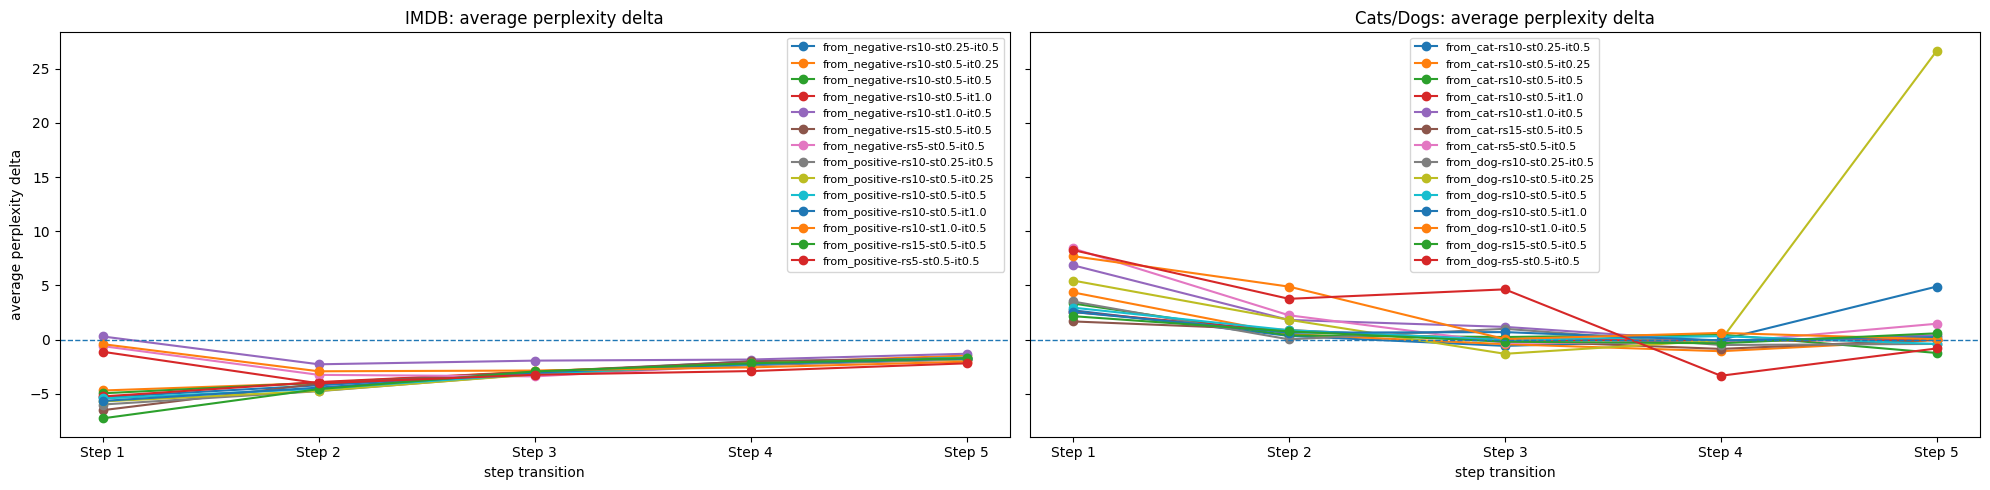

In [13]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt

imdb_path = "dlm_steer_results/42_imdb_manualsearch_csv"
catdog_path = "dlm_steer_results/42_cats_dogs_manualsearch_csv"

def get_avg_perplexity_deltas(folder):
    results = {}

    for path in sorted(glob.glob(os.path.join(folder, "*.csv"))):
        df = pd.read_csv(path)

        # 6 sentences per instance -> steps 0,1,2,3,4,5
        df["step"] = df.groupby("instance_number").cumcount()

        grid = df.pivot(
            index="instance_number",
            columns="step",
            values="perplexity"
        )

        # deltas: 0->1, 1->2, 2->3, 3->4, 4->5
        deltas = grid.diff(axis=1).iloc[:, 1:]

        avg_deltas = deltas.mean(axis=0)

        name = os.path.basename(path).replace(".csv", "")
        results[name] = avg_deltas.values

    return results


imdb_results = get_avg_perplexity_deltas(imdb_path)
catdog_results = get_avg_perplexity_deltas(catdog_path)

x = ["Step 1", "Step 2", "Step 3", "Step 4", "Step 5"]

fig, axes = plt.subplots(1, 2, figsize=(20, 5), sharey=True)

for name, vals in imdb_results.items():
    axes[0].plot(x, vals, marker="o", label=name)

axes[0].set_title("IMDB: average perplexity delta")
axes[0].set_xlabel("step transition")
axes[0].set_ylabel("average perplexity delta")
axes[0].axhline(0, linestyle="--", linewidth=1)
axes[0].legend(fontsize=8)

for name, vals in catdog_results.items():
    axes[1].plot(x, vals, marker="o", label=name)

axes[1].set_title("Cats/Dogs: average perplexity delta")
axes[1].set_xlabel("step transition")
axes[1].axhline(0, linestyle="--", linewidth=1)
axes[1].legend(fontsize=8)

fig.tight_layout()
plt.show()

In [20]:
import pandas as pd

RANDOM_STATE = 42
N_PER_TARGET = 25

timpa_paths = {
    "positive": "dlm_steer_results/42_imdb_manualsearch_csv/from_negative-rs15-st0.5-it0.5.csv",
    "negative": "dlm_steer_results/42_imdb_manualsearch_csv/from_positive-rs15-st0.5-it0.5.csv",
    "cat": "dlm_steer_results/42_cats_dogs_manualsearch_csv/from_dog-rs15-st0.5-it0.5.csv",
    "dog": "dlm_steer_results/42_cats_dogs_manualsearch_csv/from_cat-rs15-st0.5-it0.5.csv",
}

benchmark_paths = {
    "imdb": "dlm_steer_results/benchmark-imdb-scored.csv",
    "catdog": "dlm_steer_results/benchmark-cats_dogs-scored.csv",
}

def get_timpa_final(path, target_label):
    df = pd.read_csv(path)

    # each instance has 6 rows: step 0,1,2,3,4,5
    df["step"] = df.groupby("instance_number").cumcount()
    df["sample_id"] = df["instance_number"]

    original = (
        df[df["step"] == 0][["sample_id", "text"]]
        .rename(columns={"text": "Original"})
    )

    final = df[df["step"] == 5].copy()
    final = final.merge(original, on="sample_id", how="left")

    final["timpa_success"] = (
        final["predicted_label"].astype(str).str.lower().str.strip()
        == target_label
    )

    return final[[
        "sample_id",
        "Original",
        "text",
        "timpa_success",
    ]].rename(columns={"text": "TimpaTeks Result"})


def get_benchmark_final(path, target_label, dataset):
    df = pd.read_csv(path)

    # benchmark is ordered by SOURCE class
    # IMDB: first 1000 = positive source, last 1000 = negative source
    # CatDog: first 1000 = dog source, last 1000 = cat source
    if dataset == "imdb":
        if target_label == "negative":      # positive -> negative
            df = df.iloc[:1000].copy()
        elif target_label == "positive":    # negative -> positive
            df = df.iloc[1000:2000].copy()

    elif dataset == "catdog":
        if target_label == "cat":           # dog -> cat
            df = df.iloc[:1000].copy()
        elif target_label == "dog":         # cat -> dog
            df = df.iloc[1000:2000].copy()

    df = df.reset_index(drop=True)
    df["sample_id"] = df.index

    df["baseline_success"] = (
        df["predicted_label"].astype(str).str.lower().str.strip()
        == target_label
    )

    return df[[
        "sample_id",
        "output",
        "baseline_success",
    ]].rename(columns={"output": "Baseline Result"})


rows = []

for target in ["positive", "negative", "cat", "dog"]:
    dataset = "imdb" if target in ["positive", "negative"] else "catdog"

    timpa = get_timpa_final(timpa_paths[target], target)
    baseline = get_benchmark_final(
        benchmark_paths[dataset],
        target,
        dataset
    )

    paired = timpa.merge(baseline, on="sample_id", how="inner")

    paired = paired[
        paired["timpa_success"] & paired["baseline_success"]
    ].copy()

    print(target, "paired successes:", len(paired))

    sample = paired.sample(
        n=min(N_PER_TARGET, len(paired)),
        random_state=RANDOM_STATE
    ).copy()

    sample["Target"] = target

    rows.append(sample[[
        "Target",
        "Original",
        "TimpaTeks Result",
        "Baseline Result",
    ]])


comparison_df = pd.concat(rows, ignore_index=True)

comparison_df.to_csv(
    "timpa_vs_baseline_100_samples.csv",
    index=False
)

comparison_df

positive paired successes: 331
negative paired successes: 449
cat paired successes: 325
dog paired successes: 378


,Target,Original,TimpaTeks Result,Baseline Result
0,positive,"This is a movie of tired, yet weirdly childish...",This film has a very good plot and a very good...,I loved this movie. It was so scary and thrill...
1,positive,There are some redeeming qualities to this sho...,"There are some very good songs in the show, a...",I loved this movie. I thought it was a great m...
2,positive,"Patricia Hunter: Oh, professor, do you also ma...","/>Dr. Glen: Doctor, do you make it a habit of...",I like the color of the sky. I like the color ...
3,positive,"This movie was God-awful, from conception to e...","the movie's casting, The premise of the movie...",I loved this movie. It was so funny and entert...
4,positive,If this is all the Watchowski's have to offer ...,I am certain that the of Neo's character was ...,I loved this movie. I saw it in the theater an...
...,...,...,...,...
95,dog,"In the stillness of the forest, the cat hunted...","In the stillness of the night, the wolf watche...","In the silence of the forest, the dog hunted, ..."
96,dog,"Despite popular belief, cats do not have the a...","dogs. However, they do not bark in the way th...","Contrary to popular belief, dogs do not have t..."
97,dog,"The sailor, lost at sea for days on end, clung...","The sailor, lost at sea for days on end, felt ...","The sailor, lost at sea for days on end, clung..."
98,dog,"In a bustling marketplace, a cat with calico f...","At the bustling marketplace, Max, a dog known ...","In a bustling marketplace, a dog with calico f..."
